<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/class13_lab13_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: 环境初始化 & 基准朴素回归（Naive Bivariate Model）

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── 加载数据 ─────────────────────────────────────────────────
# 方法A：从本地上传（Google Colab）
from google.colab import files
print('请上传 Zillow_California_2026_Hedonic.csv')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f'\n✓ 数据加载完成：{df.shape[0]} 行 × {df.shape[1]} 列')
print(df.describe().round(2))

请上传 Zillow_California_2026_Hedonic.csv


Saving Zillow_California_2026_Hedonic.csv to Zillow_California_2026_Hedonic.csv

✓ 数据加载完成：1000 行 × 3 列
       Property_Age  Distance_to_Tech_Hub  Sale_Price
count       1000.00               1000.00     1000.00
mean          66.41                 49.54   671451.91
std           28.26                 28.92   181069.16
min            0.00                  1.50   282405.22
25%           42.60                 24.38   520887.91
50%           66.45                 50.15   660912.60
75%           89.22                 74.72   832462.60
max          131.60                100.00  1072142.05


In [3]:
# ── Step 1: 朴素二元回归（遗漏变量偏差演示）────────────────
# 仅用 Property_Age 预测 Sale_Price，故意省略 Distance_to_Tech_Hub

naive_model = smf.ols('Sale_Price ~ Property_Age', data=df).fit()
print(naive_model.summary())

naive_coef = naive_model.params['Property_Age']
print(f'\n朴素回归 Property_Age 系数：{naive_coef:,.2f}')

# ── 诊断 ─────────────────────────────────────────────────────
print('\n▶ 观察诊断：')
if naive_coef > 0:
    print('  ⚠  系数为正：朴素模型暗示房龄越大，价格越高！')
    print('  这是遗漏变量偏差（OVB）的典型症状：')
    print('  旧房子 → 靠近科技中心 → 地段溢价被错误归因于「房龄」')
else:
    print('  系数为负：房龄每增加1年，售价变化 $', round(naive_coef, 2))

                            OLS Regression Results                            
Dep. Variable:             Sale_Price   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     3105.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          1.26e-308
Time:                        01:31:46   Log-Likelihood:                -12818.
No. Observations:                1000   AIC:                         2.564e+04
Df Residuals:                     998   BIC:                         2.565e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     3.013e+05   7218.570     41.742   

## Step 2: 多元回归（控制混淆变量）

In [4]:
# ── Step 2: 多元 OLS（同时控制 Property_Age + Distance_to_Tech_Hub）

multi_model = smf.ols('Sale_Price ~ Property_Age + Distance_to_Tech_Hub', data=df).fit()
print(multi_model.summary())

multi_age_coef = multi_model.params['Property_Age']
multi_dist_coef = multi_model.params['Distance_to_Tech_Hub']

print(f'\n多元回归 Property_Age 系数：    {multi_age_coef:,.2f}')
print(f'多元回归 Distance_to_Tech_Hub 系数：{multi_dist_coef:,.2f}')

print('\n▶ 系数比较：')
print(f'  朴素回归 Age 系数：{naive_coef:,.2f}')
print(f'  多元回归 Age 系数：{multi_age_coef:,.2f}')
print(f'  变化量：{multi_age_coef - naive_coef:,.2f}')
print('\n  → 控制距离后，Age 系数发生了大幅变化！')
print('    这正是遗漏变量偏差被修正的数学证据。')
print(f'\n  Distance 系数为负（{multi_dist_coef:,.2f}）：')
print('  距科技中心越远（英里↑），售价越低 → 符合经济直觉 ✓')

                            OLS Regression Results                            
Dep. Variable:             Sale_Price   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                 1.040e+04
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:31:46   Log-Likelihood:                -11982.
No. Observations:                1000   AIC:                         2.397e+04
Df Residuals:                     997   BIC:                         2.399e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.203e+06 

## Step 3: 手动执行 FWL 定理（三步残差化证明）

FWL 定理告诉我们：多元回归中 $\hat{\beta}_{Age}$ 的值，等同于在「已剔除 Distance 影响」的净残差之间做简单回归所得的系数。

In [5]:
# ── Step 3a: 从价格中 partial out 距离的影响 ─────────────────
# 将 Sale_Price 对 Distance_to_Tech_Hub 回归，提取残差
# Price_Residuals = 剔除距离解释后，价格中「无法被距离解释」的部分

res_y_model = smf.ols('Sale_Price ~ Distance_to_Tech_Hub', data=df).fit()
df['Price_Residuals'] = res_y_model.resid

print('Step 3a 完成：Price_Residuals 已提取')
print(f'  Price_Residuals 均值（应≈0）：{df["Price_Residuals"].mean():.6f}')
print(f'  Price_Residuals 标准差：${df["Price_Residuals"].std():,.0f}')

Step 3a 完成：Price_Residuals 已提取
  Price_Residuals 均值（应≈0）：-0.000000
  Price_Residuals 标准差：$43,750


In [6]:
# ── Step 3b: 从房龄中 partial out 距离的影响 ─────────────────
# 将 Property_Age 对 Distance_to_Tech_Hub 回归，提取残差
# Age_Residuals = 剔除「旧房靠近科技中心」相关性后，房龄的纯净变异

res_x_model = smf.ols('Property_Age ~ Distance_to_Tech_Hub', data=df).fit()
df['Age_Residuals'] = res_x_model.resid

print('Step 3b 完成：Age_Residuals 已提取')
print(f'  Age_Residuals 均值（应≈0）：{df["Age_Residuals"].mean():.6f}')

# 展示 Property_Age 与 Distance 的原始负相关（OVB 的根源）
raw_corr = df['Property_Age'].corr(df['Distance_to_Tech_Hub'])
print(f'\n  Property_Age × Distance 原始相关系数：{raw_corr:.4f}')
print('  → 负相关确认：旧房子确实更靠近科技中心（OVB 机制成立）')

# 残差之间的相关性（应接近0）
resid_corr = df['Age_Residuals'].corr(df['Price_Residuals'])
print(f'  Age_Residuals × Price_Residuals 相关系数：{resid_corr:.4f}')
print('  → 残差之间的关系已被「净化」，去除了 Distance 的共同方差')

Step 3b 完成：Age_Residuals 已提取
  Age_Residuals 均值（应≈0）：0.000000

  Property_Age × Distance 原始相关系数：-0.9370
  → 负相关确认：旧房子确实更靠近科技中心（OVB 机制成立）
  Age_Residuals × Price_Residuals 相关系数：-0.4656
  → 残差之间的关系已被「净化」，去除了 Distance 的共同方差


In [7]:
# ── Step 3c: 残差对残差回归（无截距）────────────────────────
# -1 移除截距项，确保精确数学匹配
# 这是 FWL 定理的核心步骤：两个「净化后」的信号之间的纯净关系

fwl_model = smf.ols('Price_Residuals ~ Age_Residuals - 1', data=df).fit()
print(fwl_model.summary())

fwl_coef = fwl_model.params['Age_Residuals']
print(f'\nFWL 残差回归 Age_Residuals 系数：{fwl_coef:,.6f}')

                                 OLS Regression Results                                
Dep. Variable:        Price_Residuals   R-squared (uncentered):                   0.217
Model:                            OLS   Adj. R-squared (uncentered):              0.216
Method:                 Least Squares   F-statistic:                              276.5
Date:                Sat, 14 Mar 2026   Prob (F-statistic):                    5.27e-55
Time:                        01:31:46   Log-Likelihood:                         -11982.
No. Observations:                1000   AIC:                                  2.397e+04
Df Residuals:                     999   BIC:                                  2.397e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

## Step 4: 认识论证明（Epistemological Proof）— 系数完全吻合

In [8]:
# ── Step 4: 数值比较验证 ─────────────────────────────────────
print('=' * 55)
print('FWL 定理证明：系数精确匹配验证')
print('=' * 55)
print(f'  Step 1 朴素回归 Property_Age 系数：  {naive_coef:>15,.6f}')
print(f'  Step 2 多元回归 Property_Age 系数：  {multi_age_coef:>15,.6f}')
print(f'  Step 3 FWL残差回归 Age_Residuals 系数：{fwl_coef:>12,.6f}')
print('=' * 55)

# 精确比较（浮点误差阈值 1e-6）
diff = abs(multi_age_coef - fwl_coef)
print(f'\n多元回归 vs FWL 差值：{diff:.2e}')

if diff < 1e-4:
    print('✅ QED：FWL 定理证明成功！')
    print('   多元回归与三步残差化方法产生了精确相同的系数。')
    print('   这在代数上证明了 OLS 的 ceteris paribus 机制：')
    print('   算法通过超平面几何，自动完成了 FWL 的残差剥离。')
else:
    print(f'⚠  差值 {diff:.4f} 超过阈值，请检查公式。')

# OVB 量化
ovb = naive_coef - multi_age_coef
print(f'\n遗漏变量偏差（OVB）量化：')
print(f'  OVB = 朴素系数 - 真实系数 = {naive_coef:,.2f} - {multi_age_coef:,.2f} = {ovb:,.2f}')
print(f'  解读：省略距离变量，导致 Property_Age 系数被高估了 ${abs(ovb):,.2f}/年')

FWL 定理证明：系数精确匹配验证
  Step 1 朴素回归 Property_Age 系数：     5,573.630595
  Step 2 多元回归 Property_Age 系数：    -2,063.129217
  Step 3 FWL残差回归 Age_Residuals 系数：-2,063.129217

多元回归 vs FWL 差值：1.46e-11
✅ QED：FWL 定理证明成功！
   多元回归与三步残差化方法产生了精确相同的系数。
   这在代数上证明了 OLS 的 ceteris paribus 机制：
   算法通过超平面几何，自动完成了 FWL 的残差剥离。

遗漏变量偏差（OVB）量化：
  OVB = 朴素系数 - 真实系数 = 5,573.63 - -2,063.13 = 7,636.76
  解读：省略距离变量，导致 Property_Age 系数被高估了 $7,636.76/年


## Step 5: 可视化 — OVB 诊断图 + FWL 残差图

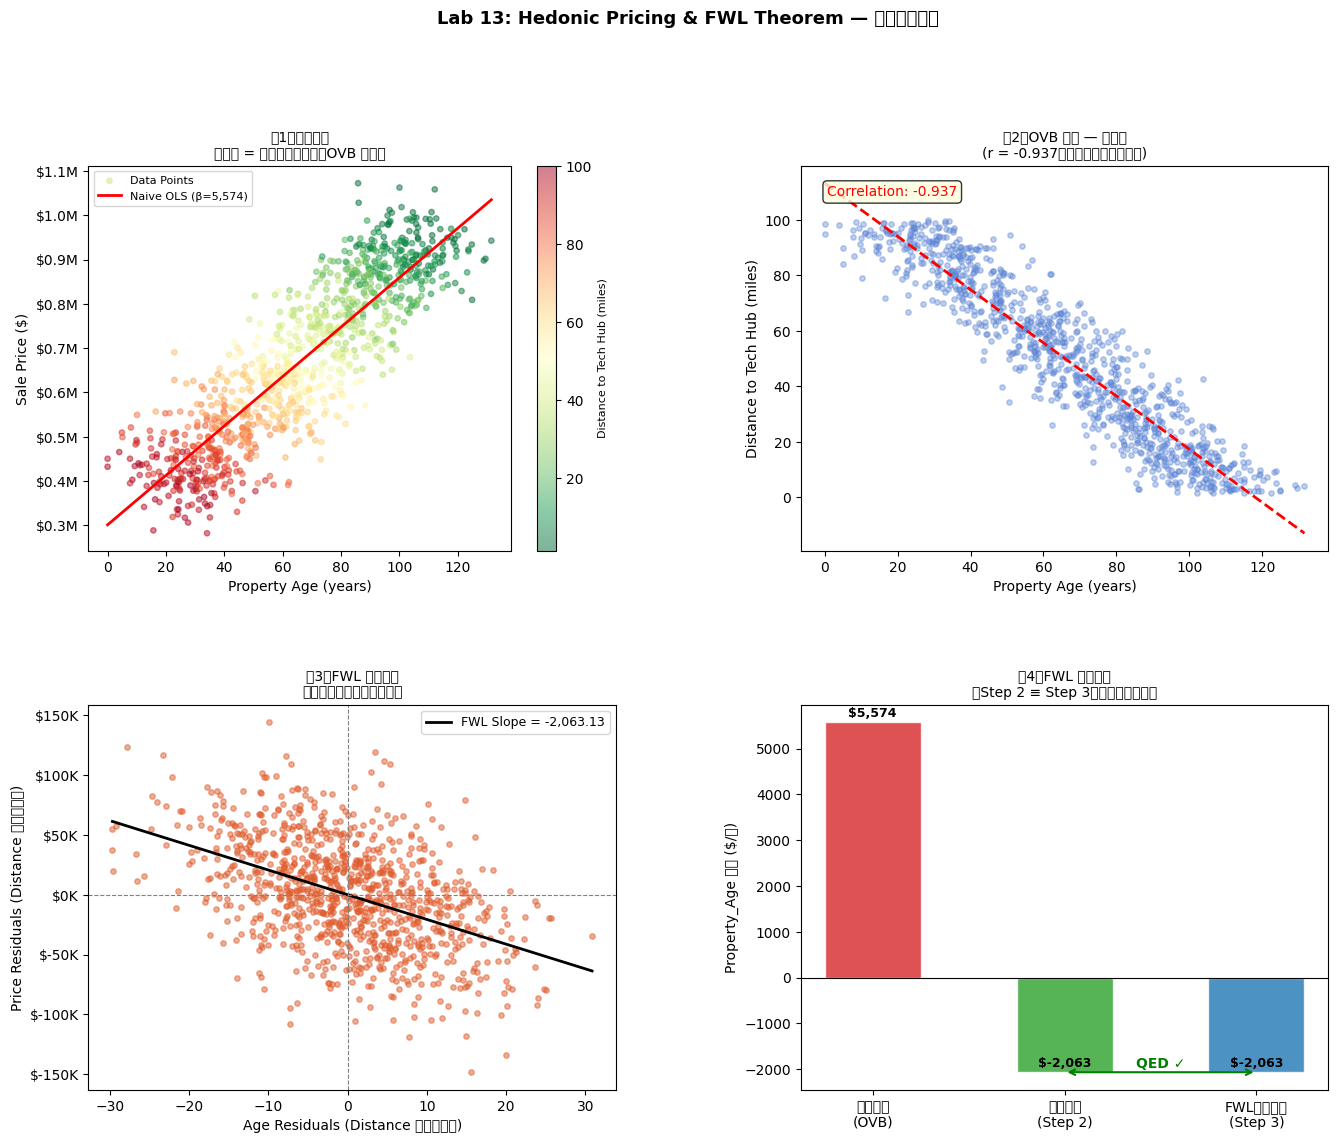


✓ 图表已保存为 lab13_FWL_panel.png


In [9]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 图1：Property_Age vs Sale_Price（朴素关系，含OVB）────────
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(df['Property_Age'], df['Sale_Price'],
                      c=df['Distance_to_Tech_Hub'], cmap='RdYlGn_r',
                      alpha=0.5, s=15, label='Data Points')
# 朴素拟合线
x_range = np.linspace(df['Property_Age'].min(), df['Property_Age'].max(), 100)
naive_line = naive_model.params['Intercept'] + naive_coef * x_range
ax1.plot(x_range, naive_line, 'r-', lw=2, label=f'Naive OLS (β={naive_coef:,.0f})')
cb1 = plt.colorbar(scatter, ax=ax1)
cb1.set_label('Distance to Tech Hub (miles)', fontsize=8)
ax1.set_xlabel('Property Age (years)')
ax1.set_ylabel('Sale Price ($)')
ax1.set_title('图1：朴素回归\n（颜色 = 距科技中心距离，OVB 根源）', fontsize=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax1.legend(fontsize=8)

# ── 图2：Property_Age vs Distance（负相关，OVB机制）─────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(df['Property_Age'], df['Distance_to_Tech_Hub'],
            alpha=0.4, s=15, color='#5c85d6')
# 拟合线
age_dist_model = smf.ols('Distance_to_Tech_Hub ~ Property_Age', data=df).fit()
trend_line = age_dist_model.params['Intercept'] + age_dist_model.params['Property_Age'] * x_range
ax2.plot(x_range, trend_line, 'r--', lw=2)
corr_val = df['Property_Age'].corr(df['Distance_to_Tech_Hub'])
ax2.set_xlabel('Property Age (years)')
ax2.set_ylabel('Distance to Tech Hub (miles)')
ax2.set_title(f'图2：OVB 根源 — 负相关\n(r = {corr_val:.3f}：旧房更靠近科技中心)', fontsize=10)
ax2.text(0.05, 0.95, f'Correlation: {corr_val:.3f}', transform=ax2.transAxes,
         fontsize=10, color='red', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── 图3：FWL 残差图（核心证明）───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(df['Age_Residuals'], df['Price_Residuals'],
            alpha=0.5, s=15, color='#e05c2d')
# FWL 拟合线（无截距）
age_res_range = np.linspace(df['Age_Residuals'].min(), df['Age_Residuals'].max(), 100)
fwl_line = fwl_coef * age_res_range
ax3.plot(age_res_range, fwl_line, 'k-', lw=2,
         label=f'FWL Slope = {fwl_coef:,.2f}')
ax3.axhline(0, color='gray', linestyle='--', lw=0.8)
ax3.axvline(0, color='gray', linestyle='--', lw=0.8)
ax3.set_xlabel('Age Residuals (Distance 影响已剔除)')
ax3.set_ylabel('Price Residuals (Distance 影响已剔除)')
ax3.set_title('图3：FWL 残差回归\n（纯净信号，无混淆偏差）', fontsize=10)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax3.legend(fontsize=9)

# ── 图4：系数对比条形图（证明精确匹配）──────────────────────
ax4 = fig.add_subplot(gs[1, 1])
models = ['朴素回归\n(OVB)', '多元回归\n(Step 2)', 'FWL残差回归\n(Step 3)']
coefs = [naive_coef, multi_age_coef, fwl_coef]
colors = ['#d62728', '#2ca02c', '#1f77b4']
bars = ax4.bar(models, coefs, color=colors, alpha=0.8, edgecolor='white', width=0.5)
for bar, coef in zip(bars, coefs):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
             f'${coef:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.axhline(0, color='black', lw=0.8)
ax4.set_ylabel('Property_Age 系数 ($/年)')
ax4.set_title('图4：FWL 定理证明\n（Step 2 ≡ Step 3，精确数值吻合）', fontsize=10)
# 添加匹配标注
ax4.annotate('', xy=(2, fwl_coef), xytext=(1, multi_age_coef),
             arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))
ax4.text(1.5, (multi_age_coef + fwl_coef)/2 + 100, 'QED ✓', ha='center',
         color='green', fontsize=10, fontweight='bold')

plt.suptitle('Lab 13: Hedonic Pricing & FWL Theorem — 完整诊断面板',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('lab13_FWL_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ 图表已保存为 lab13_FWL_panel.png')

## Step 6: AI 扩展任务 — 交互式 3D 回归超平面可视化

In [10]:
import plotly.graph_objects as go

# ── 从 statsmodels 多元回归结果中提取系数 ───────────────────
# multi_model.params 是一个 Series，索引为变量名
intercept = multi_model.params['Intercept']          # β₀：常数截距
beta_age   = multi_model.params['Property_Age']      # β₁：房龄系数
beta_dist  = multi_model.params['Distance_to_Tech_Hub']  # β₂：距离系数

print(f'超平面方程：')
print(f'Sale_Price = {intercept:,.2f} + ({beta_age:,.2f}) × Property_Age + ({beta_dist:,.2f}) × Distance_to_Tech_Hub')

# ── 生成 meshgrid（用于绘制二维超平面表面）────────────────
# np.linspace 在 X1（房龄）和 X2（距离）各自的取值范围内均匀生成 40 个网格点
age_grid  = np.linspace(df['Property_Age'].min(),        df['Property_Age'].max(),        40)
dist_grid = np.linspace(df['Distance_to_Tech_Hub'].min(), df['Distance_to_Tech_Hub'].max(), 40)

# np.meshgrid 将两个一维数组扩展为二维网格矩阵（40×40）
# AGE_GRID[i,j] = age_grid[j]，DIST_GRID[i,j] = dist_grid[i]
AGE_GRID, DIST_GRID = np.meshgrid(age_grid, dist_grid)

# 利用 OLS 系数计算每个网格点的预测价格
# 这产生了拟合超平面在整个 (Age, Distance) 空间上的价格预测曲面
PRICE_SURFACE = intercept + beta_age * AGE_GRID + beta_dist * DIST_GRID

# ── 构建 Plotly 3D 图形 ───────────────────────────────────────
fig = go.Figure()

# 层1：原始数据散点
fig.add_trace(go.Scatter3d(
    x=df['Property_Age'],
    y=df['Distance_to_Tech_Hub'],
    z=df['Sale_Price'],
    mode='markers',
    marker=dict(
        size=3,
        color=df['Sale_Price'],   # 按价格着色
        colorscale='Viridis',
        opacity=0.6,
        colorbar=dict(title='Sale Price ($)', x=1.02)
    ),
    name='Observed Data',
    hovertemplate=(
        '<b>Property Age:</b> %{x:.1f} yrs<br>'
        '<b>Distance to Hub:</b> %{y:.1f} mi<br>'
        '<b>Sale Price:</b> $%{z:,.0f}<extra></extra>'
    )
))

# 层2：OLS 拟合超平面（2D surface）
fig.add_trace(go.Surface(
    x=AGE_GRID,
    y=DIST_GRID,
    z=PRICE_SURFACE,
    colorscale='RdBu',
    opacity=0.55,
    name='OLS Hyperplane',
    showscale=False,
    hovertemplate=(
        '<b>Fitted Price:</b> $%{z:,.0f}<extra>OLS Hyperplane</extra>'
    )
))

fig.update_layout(
    title=dict(
        text='<b>Lab 13: OLS 回归超平面 — 多元对冲定价模型</b><br>'
             '<sup>蓝色曲面 = 拟合超平面，点 = 观测值，颜色 = 售价</sup>',
        x=0.5
    ),
    scene=dict(
        xaxis_title='Property Age (years)',
        yaxis_title='Distance to Tech Hub (miles)',
        zaxis_title='Sale Price ($)',
        xaxis=dict(backgroundcolor='rgb(240,240,255)'),
        yaxis=dict(backgroundcolor='rgb(240,255,240)'),
        zaxis=dict(backgroundcolor='rgb(255,248,240)'),
        camera=dict(eye=dict(x=1.6, y=-1.6, z=0.8))
    ),
    width=900, height=650,
    margin=dict(l=0, r=0, b=0, t=80)
)

fig.show()

# ── 3D 超平面解读 ─────────────────────────────────────────────
print('\n▶ 3D 超平面解读（如何理解控制混淆变量）：')
print()
print('  这个三维空间中，蓝色曲面是 OLS 拟合的「价格超平面」。')
print(f'  超平面方程：Price = {intercept:,.0f} + ({beta_age:.2f})×Age + ({beta_dist:.2f})×Distance')
print()
print('  沿 Property_Age 轴（固定 Distance）水平切开超平面：')
print(f'    → 斜率 = {beta_age:,.2f} = 控制距离后，每老1年价格下降 ${abs(beta_age):,.0f}')
print('    → 这就是 ceteris paribus（其他条件不变）的几何意义')
print()
print('  沿 Distance_to_Tech_Hub 轴（固定 Age）水平切开超平面：')
print(f'    → 斜率 = {beta_dist:,.2f} = 控制房龄后，每远1英里价格下降 ${abs(beta_dist):,.0f}')
print()
print('  FWL 定理的几何意义：')
print('  残差化操作 = 将数据投影到与 Distance 轴垂直的子空间，')
print('  消除 Distance 的贡献，剩下的纯净变异才是 β_Age 的真实信号。')

超平面方程：
Sale_Price = 1,202,971.27 + (-2,063.13) × Property_Age + (-7,964.24) × Distance_to_Tech_Hub



▶ 3D 超平面解读（如何理解控制混淆变量）：

  这个三维空间中，蓝色曲面是 OLS 拟合的「价格超平面」。
  超平面方程：Price = 1,202,971 + (-2063.13)×Age + (-7964.24)×Distance

  沿 Property_Age 轴（固定 Distance）水平切开超平面：
    → 斜率 = -2,063.13 = 控制距离后，每老1年价格下降 $2,063
    → 这就是 ceteris paribus（其他条件不变）的几何意义

  沿 Distance_to_Tech_Hub 轴（固定 Age）水平切开超平面：
    → 斜率 = -7,964.24 = 控制房龄后，每远1英里价格下降 $7,964

  FWL 定理的几何意义：
  残差化操作 = 将数据投影到与 Distance 轴垂直的子空间，
  消除 Distance 的贡献，剩下的纯净变异才是 β_Age 的真实信号。
